# CUIMC Appointment Simulation Analysis

This notebook mirrors the repository scripts:

- `run_simulation.py` loads `configs/baseline.yaml` and runs one simulation.
- `compare_scenarios.py` compares `configs/baseline.yaml` and `configs/scenario_2.yaml`.

The simulation is a day-level rolling appointment calendar with Poisson arrivals, FCFS earliest-open-day booking, delay-dependent balking and no-shows, future-day cancellations, burn-in, measurement, and cooldown periods.

In [1]:
from pathlib import Path
from dataclasses import replace
import sys

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

REPO_DIR = Path.cwd().resolve()
if not (REPO_DIR / "config_loader.py").exists():
    REPO_DIR = REPO_DIR.parent.resolve()
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from config_loader import load_config
from engine import ClinicAppointmentSimulation

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

In [2]:
if not (REPO_DIR / "configs" / "baseline.yaml").exists():
    raise FileNotFoundError("Could not find configs/baseline.yaml from the current notebook location.")

CONFIG_PATHS = {
    "Baseline": REPO_DIR / "configs" / "baseline.yaml",
    "Scenario 2": REPO_DIR / "configs" / "scenario_2.yaml",
}

CONFIG_PATHS

{'Baseline': PosixPath('/Users/alexandresepulvedadedietrich/CUIMC-Appointment-Simulation/configs/baseline.yaml'),
 'Scenario 2': PosixPath('/Users/alexandresepulvedadedietrich/CUIMC-Appointment-Simulation/configs/scenario_2.yaml')}

## Configuration

The YAML files define the booking capacity, calendar horizon, simulation periods, random seed, and class-specific arrival and behavior parameters.

In [3]:
def describe_rule(rule):
    if all(hasattr(rule, attr) for attr in ("threshold", "low", "high")):
        return f"tau <= {rule.threshold}: {rule.low:.2f}; tau > {rule.threshold}: {rule.high:.2f}"
    return rule.__class__.__name__

configs = {name: load_config(path) for name, path in CONFIG_PATHS.items()}

global_config_df = pd.DataFrame(
    [
        {
            "scenario": name,
            "slots_per_day": config.slots_per_day,
            "horizon_days": config.horizon_days,
            "burn_in_days": config.burn_in_days,
            "measure_days": config.measure_days,
            "cooldown_days": config.cooldown_days,
            "seed": config.seed,
        }
        for name, config in configs.items()
    ]
)

class_config_df = pd.DataFrame(
    [
        {
            "scenario": name,
            "class_id": class_id,
            "lambda_per_day": params.lambda_per_day,
            "cancel_prob": params.cancel_prob,
            "value": params.value,
            "balk_prob": describe_rule(params.balk_prob),
            "no_show_prob": describe_rule(params.no_show_prob),
        }
        for name, config in configs.items()
        for class_id, params in config.classes.items()
    ]
)

display(global_config_df)
display(class_config_df)

,scenario,slots_per_day,horizon_days,burn_in_days,measure_days,cooldown_days,seed
0,Baseline,32,14,30,365,10,11
1,Scenario 2,32,10,30,60,10,42


,scenario,class_id,lambda_per_day,cancel_prob,value,balk_prob,no_show_prob
0,Baseline,1,50.0,0.1,1.0,tau <= 9: 0.00; tau > 9: 0.50,tau <= 6: 0.00; tau > 6: 0.30
1,Baseline,2,50.0,0.1,1.0,tau <= 9: 0.00; tau > 9: 0.50,tau <= 6: 0.00; tau > 6: 0.30
2,Scenario 2,1,50.0,0.1,1.0,tau <= 5: 0.00; tau > 5: 1.00,tau <= 10: 0.00; tau > 10: 1.00
3,Scenario 2,2,30.0,0.1,1.0,tau <= 5: 0.00; tau > 5: 1.00,tau <= 10: 0.00; tau > 10: 1.00


## Run The Configured Scenarios

Each run constructs `ClinicAppointmentSimulation(config)` and calls `.run()`, matching the command-line scripts.

In [4]:
def run_scenario(config):
    sim = ClinicAppointmentSimulation(config)
    return sim.run()

results = {name: run_scenario(config) for name, config in configs.items()}
list(results)

['Baseline', 'Scenario 2']

In [5]:
def aggregate_delay_metrics(result):
    booked = sum(metrics.booked for metrics in result.class_metrics.values())
    offered = sum(metrics.offered for metrics in result.class_metrics.values())
    accepted_delay = sum(metrics.total_booking_delay for metrics in result.class_metrics.values())
    offered_delay = sum(metrics.total_offered_booking_delay for metrics in result.class_metrics.values())
    return {
        "mean_accepted_booking_delay": accepted_delay / booked if booked else 0,
        "mean_offered_booking_delay": offered_delay / offered if offered else 0,
    }


def aggregate_metrics_frame(results_by_name):
    rows = []
    for name, result in results_by_name.items():
        rows.append(
            {
                "scenario": name,
                "average_utilization": result.average_utilization,
                "overall_percent_serviced": result.overall_percent_serviced,
                **aggregate_delay_metrics(result),
            }
        )
    return pd.DataFrame(rows)


def class_metrics_frame(results_by_name):
    rows = []
    for name, result in results_by_name.items():
        for class_id, metrics in result.class_metrics.items():
            arrivals = metrics.arrivals
            booked = metrics.booked
            rows.append(
                {
                    "scenario": name,
                    "class_id": class_id,
                    "offered_rate": metrics.offered / arrivals if arrivals else 0,
                    "booking_rate": metrics.booked / arrivals if arrivals else 0,
                    "balk_rate": metrics.balked / arrivals if arrivals else 0,
                    "no_offer_rate": metrics.no_offer / arrivals if arrivals else 0,
                    "cancel_rate_among_booked": metrics.canceled / booked if booked else 0,
                    "no_show_rate_among_booked": metrics.no_show / booked if booked else 0,
                    "percent_serviced": metrics.percent_serviced,
                    "mean_accepted_booking_delay": metrics.mean_accepted_booking_delay,
                    "mean_offered_booking_delay": metrics.mean_offered_booking_delay,
                }
            )
    return pd.DataFrame(rows)


def slot_metrics_frame(results_by_name):
    rows = []
    for name, result in results_by_name.items():
        metrics = result.slot_metrics
        total_slots = result.total_slots
        rows.append(
            {
                "scenario": name,
                "booked_slot_rate": metrics.booked_slots / total_slots if total_slots else 0,
                "served_slot_rate": metrics.served_slots / total_slots if total_slots else 0,
                "no_show_slot_rate": metrics.no_show_slots / total_slots if total_slots else 0,
            }
        )
    return pd.DataFrame(rows)

aggregate_metrics_df = aggregate_metrics_frame(results)
class_metrics_df = class_metrics_frame(results)
slot_metrics_df = slot_metrics_frame(results)

display(
    aggregate_metrics_df.style.format(
        {
            "average_utilization": "{:.1%}",
            "overall_percent_serviced": "{:.1%}",
            "mean_accepted_booking_delay": "{:.2f}",
            "mean_offered_booking_delay": "{:.2f}",
        }
    )
)

display(
    class_metrics_df.style.format(
        {
            "offered_rate": "{:.1%}",
            "booking_rate": "{:.1%}",
            "balk_rate": "{:.1%}",
            "no_offer_rate": "{:.1%}",
            "cancel_rate_among_booked": "{:.1%}",
            "no_show_rate_among_booked": "{:.1%}",
            "percent_serviced": "{:.1%}",
            "mean_accepted_booking_delay": "{:.2f}",
            "mean_offered_booking_delay": "{:.2f}",
        }
    )
)

display(
    slot_metrics_df.style.format(
        {
            "booked_slot_rate": "{:.1%}",
            "served_slot_rate": "{:.1%}",
            "no_show_slot_rate": "{:.1%}",
        }
    )
)

,scenario,average_utilization,overall_percent_serviced,mean_accepted_booking_delay,mean_offered_booking_delay
0,Baseline,83.4%,26.5%,8.52,9.50
1,Scenario 2,100.0%,40.8%,4.29,5.03


,scenario,class_id,offered_rate,booking_rate,balk_rate,no_offer_rate,cancel_rate_among_booked,no_show_rate_among_booked,percent_serviced,mean_accepted_booking_delay,mean_offered_booking_delay
0,Baseline,1,100.0%,64.2%,35.8%,0.0%,50.4%,8.4%,26.4%,8.53,9.51
1,Baseline,2,100.0%,63.8%,36.2%,0.0%,50.3%,8.0%,26.5%,8.50,9.50
2,Scenario 2,1,100.0%,56.4%,43.6%,0.0%,27.4%,0.0%,41.0%,4.28,5.03
3,Scenario 2,2,100.0%,56.9%,43.1%,0.0%,28.9%,0.0%,40.4%,4.32,5.04


,scenario,booked_slot_rate,served_slot_rate,no_show_slot_rate
0,Baseline,100.0%,83.4%,16.6%
1,Scenario 2,100.0%,100.0%,0.0%


## State Snapshots

The engine records a start-of-day summary state for every measured day after cancellations and before new arrivals. The rows below show `X_i,r`, the number of class `i` patients already scheduled for residual day `r`, on the first measured day.

In [6]:
def summary_state_to_frame(summary_state):
    horizon = len(next(iter(summary_state.values())))
    return pd.DataFrame.from_dict(
        summary_state,
        orient="index",
        columns=[f"D+{r}" for r in range(horizon)],
    ).rename_axis("class_id")


def full_state_to_frame(result):
    if not result.final_full_state:
        return pd.DataFrame()
    return pd.DataFrame(
        result.final_full_state,
        columns=[f"slot_{j + 1}" for j in range(len(result.final_full_state[0]))],
    ).rename_axis("residual_day")

for name, result in results.items():
    print(f"{name}: first measured-day summary state")
    display(summary_state_to_frame(result.daily_summary_states[0]))

print("Final day-level calendar view after cooldown: Baseline")
display(full_state_to_frame(results["Baseline"]))

Baseline: first measured-day summary state


,D+0,D+1,D+2,D+3,D+4,D+5,D+6,D+7,D+8,D+9,D+10,D+11,D+12,D+13
class_id,,,,,,,,,,,,,,
1,14,14,19,16,17,16,20,12,8,14,16,0,0,0
2,18,18,12,11,12,14,10,17,23,14,8,0,0,0


Scenario 2: first measured-day summary state


,D+0,D+1,D+2,D+3,D+4,D+5,D+6,D+7,D+8,D+9
class_id,,,,,,,,,,
1,28,15,21,19,17,0,0,0,0,0
2,4,10,10,9,11,0,0,0,0,0


Final day-level calendar view after cooldown: Baseline


,slot_1,slot_2,slot_3,slot_4,slot_5,slot_6,slot_7,slot_8,slot_9,slot_10,slot_11,slot_12,slot_13,slot_14,slot_15,slot_16,slot_17,slot_18,slot_19,slot_20,slot_21,slot_22,slot_23,slot_24,slot_25,slot_26,slot_27,slot_28,slot_29,slot_30,slot_31,slot_32
residual_day,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,"(2, 11)","(1, 11)","(1, 11)","(1, 11)","(1, 11)","(2, 11)","(2, 11)","(1, 11)","(2, 11)","(2, 10)","(2, 10)","(2, 10)","(2, 10)","(2, 8)","(2, 7)","(2, 7)","(1, 6)","(2, 6)","(1, 6)","(2, 6)","(1, 5)","(1, 5)","(2, 4)","(1, 4)","(2, 3)","(1, 3)","(1, 2)","(1, 2)","(1, 2)","(1, 1)","(1, 1)","(2, 1)"
1,"(2, 11)","(1, 11)","(1, 11)","(2, 11)","(2, 11)","(1, 11)","(2, 11)","(2, 11)","(1, 11)","(2, 11)","(2, 11)","(1, 11)","(2, 11)","(2, 10)","(1, 10)","(1, 10)","(2, 9)","(2, 9)","(2, 8)","(1, 7)","(1, 7)","(1, 7)","(1, 5)","(1, 4)","(2, 4)","(2, 4)","(1, 3)","(2, 2)","(1, 2)","(1, 1)","(2, 1)","(2, 1)"
2,"(1, 11)","(2, 11)","(2, 11)","(1, 11)","(2, 11)","(1, 11)","(1, 11)","(1, 11)","(1, 11)","(2, 11)","(1, 11)","(1, 11)","(2, 10)","(2, 7)","(1, 7)","(1, 7)","(1, 7)","(2, 6)","(2, 6)","(1, 6)","(2, 5)","(2, 5)","(2, 5)","(2, 4)","(1, 4)","(2, 3)","(2, 3)","(1, 3)","(2, 2)","(1, 2)","(2, 2)","(1, 2)"
3,"(2, 11)","(2, 11)","(2, 11)","(2, 11)","(1, 11)","(2, 11)","(2, 11)","(2, 11)","(2, 11)","(1, 11)","(1, 11)","(2, 11)","(2, 11)","(1, 10)","(1, 10)","(1, 9)","(2, 9)","(2, 9)","(1, 8)","(1, 7)","(2, 7)","(1, 7)","(2, 7)","(1, 7)","(1, 6)","(1, 6)","(1, 6)","(1, 5)","(2, 4)","(1, 3)","(1, 3)","(2, 3)"
4,"(2, 12)","(2, 12)","(1, 11)","(1, 11)","(2, 11)","(2, 11)","(1, 11)","(1, 11)","(2, 11)","(1, 11)","(2, 11)","(2, 11)","(2, 11)","(2, 11)","(2, 11)","(1, 11)","(2, 11)","(1, 11)","(1, 11)","(1, 9)","(1, 9)","(1, 7)","(1, 6)","(1, 6)","(1, 6)","(1, 5)","(2, 5)","(1, 5)","(2, 5)","(2, 4)","(2, 4)","(2, 4)"
5,"(1, 11)","(2, 11)","(2, 11)","(2, 11)","(2, 11)","(2, 11)","(1, 11)","(1, 11)","(2, 11)","(1, 11)","(1, 11)","(1, 11)","(1, 11)","(2, 11)","(1, 11)","(2, 11)","(2, 10)","(1, 10)","(1, 10)","(1, 10)","(1, 10)","(1, 9)","(2, 9)","(2, 8)","(2, 8)","(2, 7)","(1, 7)","(2, 7)","(2, 6)","(2, 6)","(1, 5)","(2, 5)"
6,"(2, 12)","(1, 12)","(2, 12)","(1, 11)","(1, 11)","(2, 11)","(1, 11)","(1, 11)","(1, 11)","(1, 11)","(2, 11)","(2, 11)","(2, 11)","(1, 11)","(1, 11)","(1, 10)","(2, 10)","(1, 10)","(1, 10)","(1, 10)","(1, 10)","(2, 9)","(2, 8)","(1, 8)","(1, 8)","(1, 8)","(1, 7)","(2, 6)","(2, 6)","(1, 6)","(1, 6)","(2, 6)"
7,"(2, 11)","(1, 11)","(1, 11)","(1, 11)","(1, 11)","(1, 11)","(2, 11)","(2, 11)","(1, 11)","(2, 11)","(2, 11)","(1, 11)","(2, 11)","(1, 11)","(2, 11)","(2, 10)","(1, 10)","(1, 10)","(1, 10)","(1, 9)","(2, 9)","(2, 9)","(2, 9)","(1, 8)","(1, 8)","(2, 8)","(1, 8)","(2, 8)","(2, 7)","(2, 7)","(1, 7)","(1, 7)"
8,"(2, 11)","(1, 11)","(2, 11)","(2, 11)","(2, 11)","(1, 11)","(1, 11)","(2, 11)","(1, 11)","(1, 11)","(1, 11)","(1, 11)","(2, 11)","(2, 11)","(2, 11)","(1, 11)","(1, 11)","(2, 11)","(1, 11)","(1, 10)","(2, 10)","(2, 10)","(1, 10)","(1, 10)","(2, 10)","(1, 10)","(2, 10)","(1, 10)","(1, 10)","(1, 9)","(1, 9)","(1, 8)"


## Scenario-Level Outputs

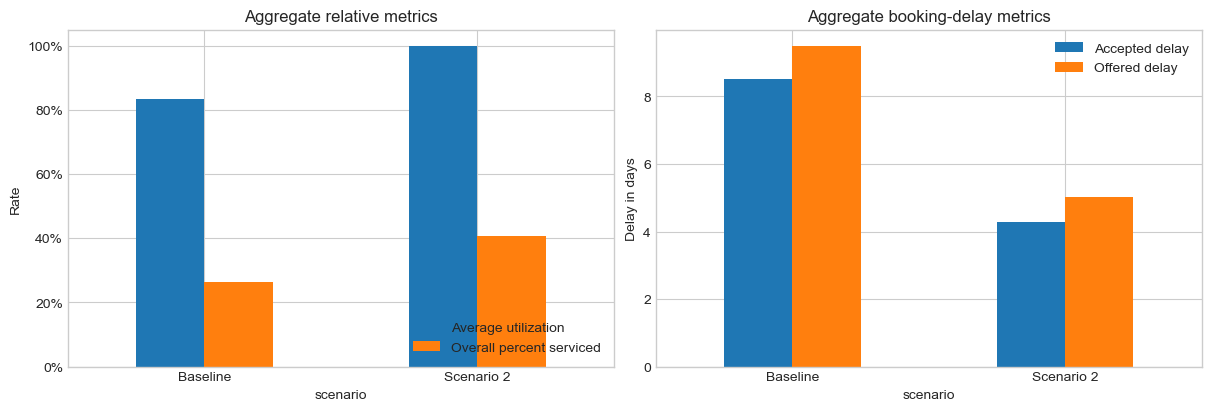

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

rate_cols = ["average_utilization", "overall_percent_serviced"]
aggregate_metrics_df.set_index("scenario")[rate_cols].plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Aggregate relative metrics")
axes[0].set_ylabel("Rate")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend(["Average utilization", "Overall percent serviced"], loc="lower right")

aggregate_metrics_df.set_index("scenario")[["mean_accepted_booking_delay", "mean_offered_booking_delay"]].plot(
    kind="bar",
    ax=axes[1],
    rot=0,
)
axes[1].set_title("Aggregate booking-delay metrics")
axes[1].set_ylabel("Delay in days")
axes[1].legend(["Accepted delay", "Offered delay"], loc="upper right")

plt.show()

## Patient Flow By Class

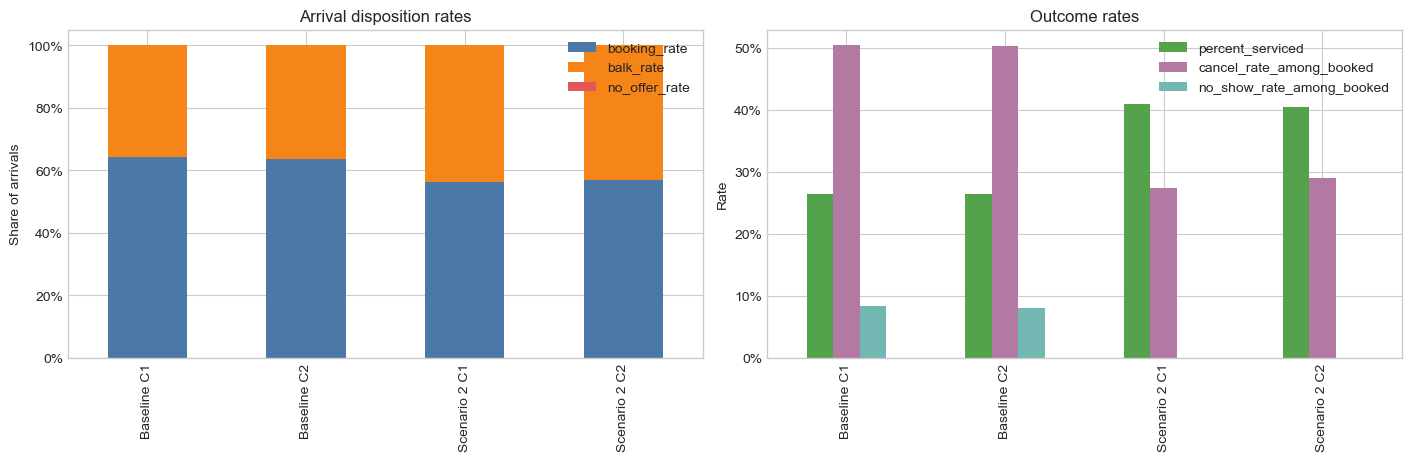

In [8]:
flow_df = class_metrics_df.copy()
flow_df["scenario_class"] = flow_df["scenario"] + " C" + flow_df["class_id"].astype(str)
flow_df = flow_df.set_index("scenario_class")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

flow_df[["booking_rate", "balk_rate", "no_offer_rate"]].plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=["#4C78A8", "#F58518", "#E45756"],
)
axes[0].set_title("Arrival disposition rates")
axes[0].set_ylabel("Share of arrivals")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend(loc="upper right")

flow_df[["percent_serviced", "cancel_rate_among_booked", "no_show_rate_among_booked"]].plot(
    kind="bar",
    ax=axes[1],
    color=["#54A24B", "#B279A2", "#72B7B2"],
)
axes[1].set_title("Outcome rates")
axes[1].set_ylabel("Rate")
axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend(loc="upper right")

plt.show()

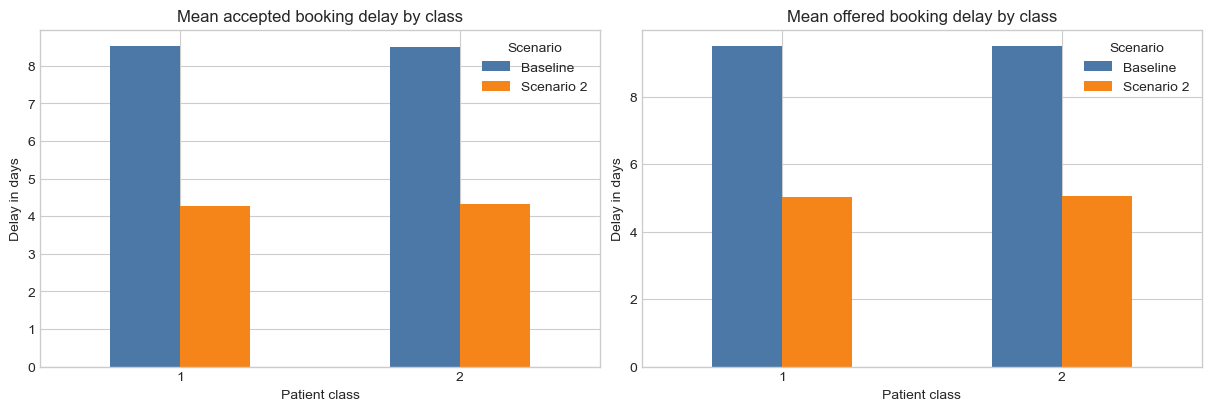

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

accepted_delay_df = class_metrics_df.pivot(index="class_id", columns="scenario", values="mean_accepted_booking_delay")
offered_delay_df = class_metrics_df.pivot(index="class_id", columns="scenario", values="mean_offered_booking_delay")

accepted_delay_df.plot(kind="bar", ax=axes[0], rot=0, color=["#4C78A8", "#F58518"])
axes[0].set_title("Mean accepted booking delay by class")
axes[0].set_xlabel("Patient class")
axes[0].set_ylabel("Delay in days")
axes[0].legend(title="Scenario")

offered_delay_df.plot(kind="bar", ax=axes[1], rot=0, color=["#4C78A8", "#F58518"])
axes[1].set_title("Mean offered booking delay by class")
axes[1].set_xlabel("Patient class")
axes[1].set_ylabel("Delay in days")
axes[1].legend(title="Scenario")

plt.show()

## Calendar Load During Measurement

The heatmaps use the recorded start-of-day summary states. Each cell is the total number of patients already scheduled at the start of a measured day for residual day `r`.

In [10]:
def summary_state_records(results_by_name):
    records = []
    for scenario, result in results_by_name.items():
        for measured_day, summary_state in enumerate(result.daily_summary_states):
            for class_id, counts in summary_state.items():
                for residual_day, booked_count in enumerate(counts):
                    records.append(
                        {
                            "scenario": scenario,
                            "measured_day": measured_day,
                            "class_id": class_id,
                            "residual_day": residual_day,
                            "booked_count": booked_count,
                        }
                    )
    return pd.DataFrame(records)

summary_state_df = summary_state_records(results)
summary_state_df.head()

,scenario,measured_day,class_id,residual_day,booked_count
0,Baseline,0,1,0,14
1,Baseline,0,1,1,14
2,Baseline,0,1,2,19
3,Baseline,0,1,3,16
4,Baseline,0,1,4,17


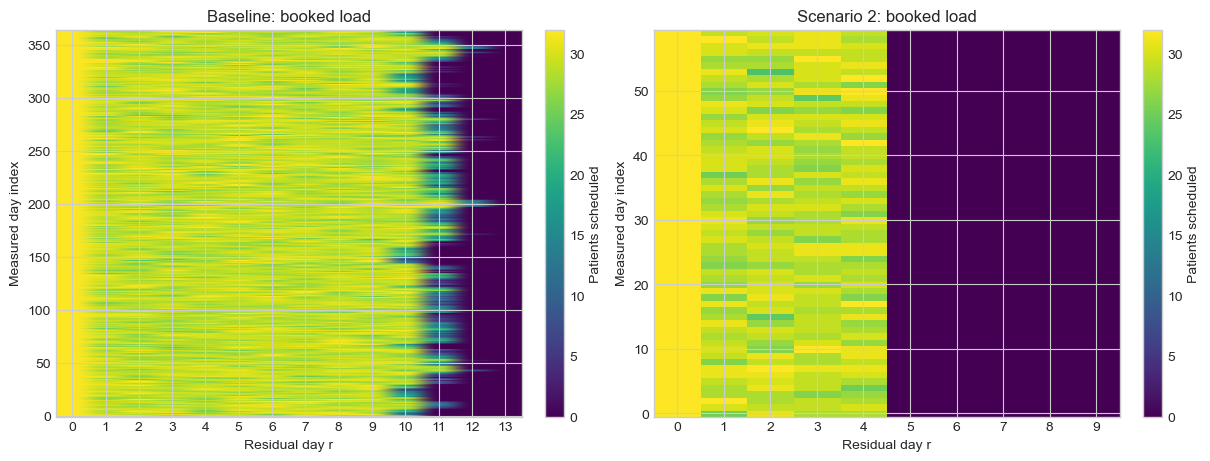

In [11]:
scenario_names = list(results)
fig, axes = plt.subplots(1, len(scenario_names), figsize=(6 * len(scenario_names), 4.5), constrained_layout=True, squeeze=False)

for ax, scenario in zip(axes.ravel(), scenario_names):
    heatmap_df = (
        summary_state_df.loc[summary_state_df["scenario"] == scenario]
        .groupby(["measured_day", "residual_day"], as_index=False)["booked_count"]
        .sum()
        .pivot(index="measured_day", columns="residual_day", values="booked_count")
        .sort_index()
    )
    image = ax.imshow(heatmap_df.values, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(f"{scenario}: booked load")
    ax.set_xlabel("Residual day r")
    ax.set_ylabel("Measured day index")
    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns)
    fig.colorbar(image, ax=ax, label="Patients scheduled")

plt.show()

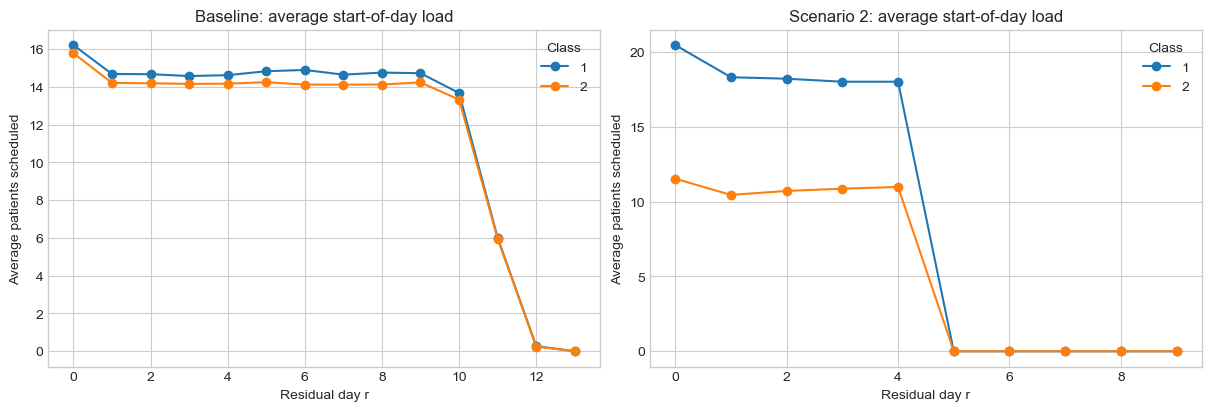

In [12]:
fig, axes = plt.subplots(1, len(scenario_names), figsize=(6 * len(scenario_names), 4), constrained_layout=True, squeeze=False)

for ax, scenario in zip(axes.ravel(), scenario_names):
    average_profile = (
        summary_state_df.loc[summary_state_df["scenario"] == scenario]
        .groupby(["residual_day", "class_id"])["booked_count"]
        .mean()
        .unstack("class_id")
    )
    average_profile.plot(marker="o", ax=ax)
    ax.set_title(f"{scenario}: average start-of-day load")
    ax.set_xlabel("Residual day r")
    ax.set_ylabel("Average patients scheduled")
    ax.legend(title="Class")

plt.show()

## Replication Check

A single seed is useful for debugging, but the model is stochastic. This section re-runs each scenario with shared replicate seeds so the plots show run-to-run variability.

In [13]:
N_REPLICATIONS = 50
REPLICATION_SEED_START = 10_000


def run_replications(configs_by_name, n_replications=N_REPLICATIONS, seed_start=REPLICATION_SEED_START):
    records = []
    for scenario, config in configs_by_name.items():
        for replication in range(n_replications):
            seeded_config = replace(config, seed=seed_start + replication)
            result = ClinicAppointmentSimulation(seeded_config).run()
            records.append(
                {
                    "scenario": scenario,
                    "replication": replication,
                    "seed": seeded_config.seed,
                    "average_utilization": result.average_utilization,
                    "overall_percent_serviced": result.overall_percent_serviced,
                    **aggregate_delay_metrics(result),
                }
            )
    return pd.DataFrame(records)

replication_df = run_replications(configs)
replication_summary_df = (
    replication_df.groupby("scenario")
    .agg(
        average_utilization_mean=("average_utilization", "mean"),
        average_utilization_std=("average_utilization", "std"),
        overall_percent_serviced_mean=("overall_percent_serviced", "mean"),
        overall_percent_serviced_std=("overall_percent_serviced", "std"),
        mean_accepted_booking_delay_mean=("mean_accepted_booking_delay", "mean"),
        mean_accepted_booking_delay_std=("mean_accepted_booking_delay", "std"),
        mean_offered_booking_delay_mean=("mean_offered_booking_delay", "mean"),
        mean_offered_booking_delay_std=("mean_offered_booking_delay", "std"),
    )
    .reset_index()
)

display(replication_summary_df.style.format({col: "{:.3f}" for col in replication_summary_df.columns if col != "scenario"}))

,scenario,average_utilization_mean,average_utilization_std,overall_percent_serviced_mean,overall_percent_serviced_std,mean_accepted_booking_delay_mean,mean_accepted_booking_delay_std,mean_offered_booking_delay_mean,mean_offered_booking_delay_std
0,Baseline,0.841,0.004,0.269,0.002,8.352,0.073,9.314,0.080
1,Scenario 2,1.000,0.000,0.399,0.006,4.292,0.017,5.048,0.020


/var/folders/qb/g17v2g6s5hb2vnxkq2tq47_r0000gn/T/ipykernel_51042/2341132301.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=scenario_names, patch_artist=True)
/var/folders/qb/g17v2g6s5hb2vnxkq2tq47_r0000gn/T/ipykernel_51042/2341132301.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=scenario_names, patch_artist=True)
/var/folders/qb/g17v2g6s5hb2vnxkq2tq47_r0000gn/T/ipykernel_51042/2341132301.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=scenario_names, patch_artist=True)
/var/folders/qb/g17v2g6s5hb2vnxkq2tq47_r000

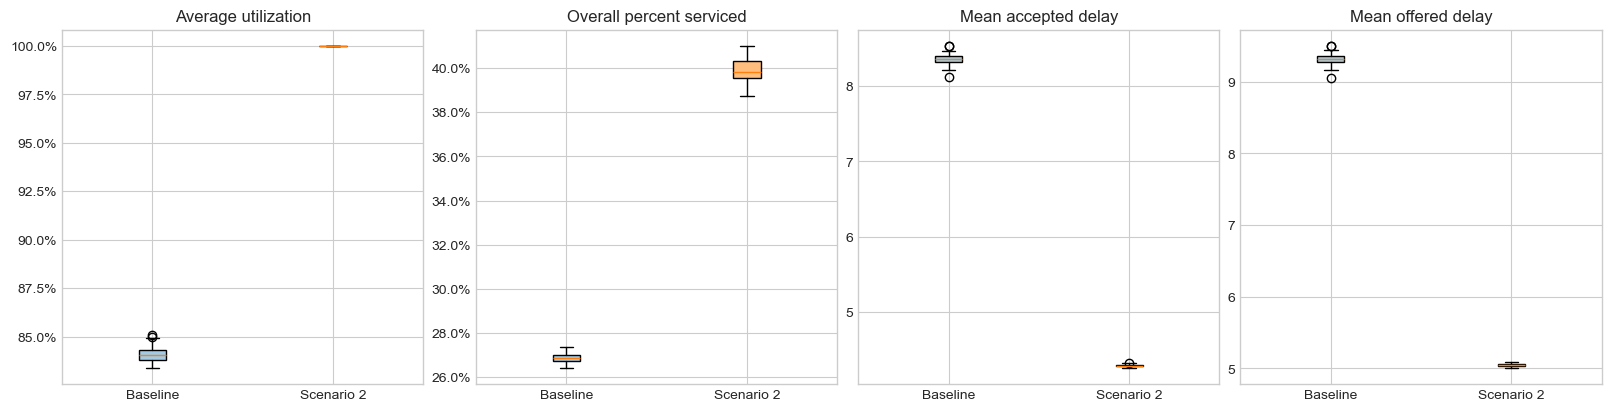

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
box_metrics = [
    "average_utilization",
    "overall_percent_serviced",
    "mean_accepted_booking_delay",
    "mean_offered_booking_delay",
]
box_titles = [
    "Average utilization",
    "Overall percent serviced",
    "Mean accepted delay",
    "Mean offered delay",
]

for ax, metric, title in zip(axes, box_metrics, box_titles):
    data = [replication_df.loc[replication_df["scenario"] == scenario, metric] for scenario in scenario_names]
    box = ax.boxplot(data, labels=scenario_names, patch_artist=True)
    for patch, color in zip(box["boxes"], ["#A0CBE8", "#FFBE7D"]):
        patch.set_facecolor(color)
    ax.set_title(title)
    ax.set_xlabel("")
    if metric in {"average_utilization", "overall_percent_serviced"}:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.show()

## Notes For Further Runs

Change `CONFIG_PATHS` to add or remove YAML scenarios. Change `N_REPLICATIONS` for a faster or more stable replication check.